In [2]:
!pip install transformers torch accelerate pandas scikit-learn openpyxl

In [3]:
# import libraries
import pandas as pd
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import pandas as pd
from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
uploaded = files.upload()

Saving master_headlines.csv to master_headlines.csv


In [5]:
full_df = pd.read_csv(next(iter(uploaded)))

print(full_df.head())
print("\nColumns:")
print(full_df.columns.tolist())

print("\nTotal Headlines:", len(full_df))

                           source  \
0                    Airdrie News   
1                      Al Jazeera   
2              Allafrica Tanzania   
3              Allafrica Tanzania   
4  Ani (asian News International)   

                                            headline            published  \
0  Commonwealth Games: Canada claims first gold m...  2026-07-24 21:18:58   
1  Which matches and tournaments can football fan...  2026-07-24 23:25:15   
2  Uganda: AFCON 2027 - A Golden Opportunity for ...  2026-07-24 20:41:56   
3  Uganda: Here Comes the Mandatory Monthly Natio...  2026-07-24 20:41:51   
4  Merck Foundation marks 'World Assisted Reprodu...  2026-07-25 00:00:00   

                                                link  
0  https://www.airdriecityview.com/national-sport...  
1  https://www.aljazeera.com/sports/2026/7/24/wha...  
2    https://allafrica.com/stories/202607240682.html  
3    https://allafrica.com/stories/202607240671.html  
4  https://www.aninews.in/news/business

In [6]:
# Hybrid Auto-Labeling with Manual Review Flagging
# ---------------------------------------------------
# Instead of forcing an automated decision everywhere, this labels
# high-confidence cases automatically and FLAGS uncertain ones (including
# financial headlines, which get FinBERT but still get double-checked)
# for the team to manually review -- combining automation's speed with
# human judgment exactly where the models struggle.

import pandas as pd
from transformers import pipeline

CONFIDENCE_THRESHOLD = 0.75  # below this, flag for manual review regardless of label

FINANCIAL_SOURCES = {"business daily africa", "standard - business"}
FINANCIAL_KEYWORDS = [
    "profit", "shares", "ipo", "bank", "sh", "ksh", "tax", "revenue",
    "loan", "investment", "market", "stock", "earnings", "trade",
    "export", "import", "fund", "economy", "gdp", "inflation", "budget"
]


def is_financial(row):
    source = str(row.get("source", "")).strip().lower()
    headline = str(row.get("headline", "")).lower()
    if source in FINANCIAL_SOURCES:
        return True
    return any(k in headline for k in FINANCIAL_KEYWORDS)


general_classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None
)
finbert_classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")


def label_row(headline, financial):
    classifier = finbert_classifier if financial else general_classifier

    if financial:
        result = classifier(str(headline), truncation=True)[0]
        label, confidence = result["label"].capitalize(), result["score"]
    else:
        scores = classifier(str(headline), truncation=True)[0]
        top = max(scores, key=lambda x: x["score"])
        label, confidence = top["label"].capitalize(), top["score"]

    needs_review = confidence < CONFIDENCE_THRESHOLD
    return label, confidence, needs_review


full_df["is_financial"] = full_df.apply(is_financial, axis=1)

results = full_df.apply(
    lambda row: label_row(row["headline"], row["is_financial"]), axis=1
)
full_df["Model_Label"] = results.apply(lambda x: x[0])
full_df["Model_Confidence"] = results.apply(lambda x: x[1])
full_df["Needs_Manual_Review"] = results.apply(lambda x: x[2])

# Summary -- this tells you how much manual work is actually left
total = len(full_df)
flagged = full_df["Needs_Manual_Review"].sum()
print(f"Total headlines: {total}")
print(f"Auto-labeled with high confidence: {total - flagged} ({(total-flagged)/total*100:.1f}%)")
print(f"Flagged for manual review: {flagged} ({flagged/total*100:.1f}%)")

# Export just the flagged rows for the team to manually check
review_queue = full_df[full_df["Needs_Manual_Review"]][
    ["source", "headline", "Model_Label", "Model_Confidence", "is_financial"]
].copy()
review_queue["final_sentiment"] = ""  # to be filled in manually
review_queue.to_csv("needs_manual_review.csv", index=False)
print(f"\nSaved {len(review_queue)} rows to needs_manual_review.csv")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Total headlines: 2537
Auto-labeled with high confidence: 1350 (53.2%)
Flagged for manual review: 1187 (46.8%)

Saved 1187 rows to needs_manual_review.csv


In [7]:
# # Domain-Routed Labeling: Financial headlines -> FinBERT, rest -> hybrid
# # --------------------------------------------------------------------------
# # Business/financial headlines use restrained, factual language ("profit",
# # "expansion", "backing") that general sentiment models read as neutral.
# # FinBERT is trained specifically on financial news and understands this
# # genre's tone. Everything else keeps using the existing cardiffnlp+siebert
# # hybrid, since that's tuned for general text.

# import pandas as pd
# from transformers import pipeline

# # --- Step 1: detect financial/business headlines ---

# FINANCIAL_SOURCES = {
#     "business daily africa", "standard - business"
#     # add other business-focused sources/sections from your dataset if relevant
#     # (dropped "the star" -- it covers all topics, not just business, so
#     # blanket-marking it financial would misroute non-business stories)
# }

# FINANCIAL_KEYWORDS = [
#     "profit", "shares", "ipo", "bank", "sh", "ksh", "tax", "revenue",
#     "loan", "investment", "market", "stock", "earnings", "trade",
#     "export", "import", "fund", "economy", "gdp", "inflation", "budget"
# ]


# def is_financial(row):
#     source = str(row.get("source", "")).strip().lower()
#     headline = str(row.get("headline", "")).lower()

#     if source in FINANCIAL_SOURCES:
#         return True
#     return any(keyword in headline for keyword in FINANCIAL_KEYWORDS)


# full_df["is_financial"] = full_df.apply(is_financial, axis=1)
# print(f"Financial headlines detected: {full_df['is_financial'].sum()} of {len(full_df)}")

# # --- Step 2: load FinBERT for the financial subset ---

# finbert_classifier = pipeline(
#     "sentiment-analysis",
#     model="ProsusAI/finbert"
# )

# financial_mask = full_df["is_financial"]
# financial_headlines = full_df.loc[financial_mask, "headline"].astype(str).tolist()

# if financial_headlines:
#     finbert_results = finbert_classifier(financial_headlines, truncation=True)
#     full_df.loc[financial_mask, "Model_Label"] = [
#         r["label"].capitalize() for r in finbert_results
#     ]
#     full_df.loc[financial_mask, "Label_Source"] = "finbert"

# # --- Step 3: everything else keeps its existing hybrid label ---
# # (assumes hybrid_label() from the previous step already populated
# # Model_Label / Label_Source for all rows -- this just overwrites the
# # financial subset with FinBERT's opinion instead)

# print("\nLabel source breakdown:")
# print(full_df["Label_Source"].value_counts())

In [8]:
# classifier = pipeline(
#     "sentiment-analysis",
#     model="siebert/sentiment-roberta-large-english"
# )

In [9]:
# predictions = classifier(
#     full_df["headline"].astype(str).tolist(),
#     batch_size=32,
#     truncation=True
# )

# full_df["Model_Label"] = [
#     prediction["label"].capitalize()
#     for prediction in predictions
# ]

In [10]:
full_df.to_csv(
    "automatically_labelled_dataset.csv",
    index=False
)

print("Automatic labelling complete.")

Automatic labelling complete.


In [11]:
uploaded_manual = files.upload()

Saving manual_labels_sample.csv to manual_labels_sample.csv


In [12]:
manual_df = pd.read_csv(next(iter(uploaded_manual)))

print(manual_df.head())
print(manual_df.columns.tolist())
print("Rows:", len(manual_df))

                  source                                           headline  \
0  Business Daily Africa  Why trio in cannabis trafficking case lost six...   
1  Business Daily Africa  Africa contributes over 40pc of Kenya's export...   
2  Business Daily Africa  SafariLink steps up fleet expansion as tourism...   
3  Business Daily Africa        M-Pesa joint venture in first Sh102m profit   
4  Business Daily Africa  Industrial sugar imports surge on improved pro...   

                       published  \
0  Sun, 19 Jul 2026 18:55:34 GMT   
1  Sun, 19 Jul 2026 17:48:12 GMT   
2  Sun, 19 Jul 2026 16:40:16 GMT   
3  Sun, 19 Jul 2026 16:23:55 GMT   
4  Sun, 19 Jul 2026 06:18:16 GMT   

                                                link sentiment  
0  https://www.businessdailyafrica.com/bd/economy...  Negative  
1  https://www.businessdailyafrica.com/bd/economy...  positive  
2  https://www.businessdailyafrica.com/bd/corpora...  positive  
3  https://www.businessdailyafrica.com/bd/corpor

In [13]:
manual_df = pd.read_csv(
    next(iter(uploaded_manual)),
    header=None
)

manual_df.columns = [
    "source",
    "headline",
    "published",
    "link",
    "Label"
]

print(manual_df.head())
print(manual_df.columns.tolist())
print("Rows:", len(manual_df))

                  source                                           headline  \
0                 source                                           headline   
1  Business Daily Africa  Why trio in cannabis trafficking case lost six...   
2  Business Daily Africa  Africa contributes over 40pc of Kenya's export...   
3  Business Daily Africa  SafariLink steps up fleet expansion as tourism...   
4  Business Daily Africa        M-Pesa joint venture in first Sh102m profit   

                       published  \
0                      published   
1  Sun, 19 Jul 2026 18:55:34 GMT   
2  Sun, 19 Jul 2026 17:48:12 GMT   
3  Sun, 19 Jul 2026 16:40:16 GMT   
4  Sun, 19 Jul 2026 16:23:55 GMT   

                                                link      Label  
0                                               link  sentiment  
1  https://www.businessdailyafrica.com/bd/economy...   Negative  
2  https://www.businessdailyafrica.com/bd/economy...   positive  
3  https://www.businessdailyafrica.com/bd/co

In [14]:
evaluation_df = pd.merge(
    manual_df,
    full_df[["headline","Model_Label","Needs_Manual_Review","Model_Confidence"]],
    on="headline",
    how="inner"
)

print("Rows matched:", len(evaluation_df))

Rows matched: 288


In [15]:
evaluation_df["Label"] = (
    evaluation_df["Label"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

evaluation_df["Model_Label"] = (
    evaluation_df["Model_Label"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

In [16]:
evaluation_df["Agreement"] = (
    evaluation_df["Label"] ==
    evaluation_df["Model_Label"]
)

In [17]:
agreement_rate = evaluation_df["Agreement"].mean() * 100

print(f"Agreement Rate: {agreement_rate:.2f}%")

Agreement Rate: 43.75%


In [18]:
confident_df = evaluation_df[~evaluation_df["Needs_Manual_Review"]]
flagged_df = evaluation_df[evaluation_df["Needs_Manual_Review"]]

if len(confident_df) > 0:
    print(f"HIGH-CONFIDENCE (auto-labeled): {len(confident_df)} rows")
    print(f"  Accuracy: {confident_df['Agreement'].mean() * 100:.2f}%\n")

if len(flagged_df) > 0:
    print(f"FLAGGED FOR REVIEW: {len(flagged_df)} rows")
    print(f"  Accuracy if trusted anyway: {flagged_df['Agreement'].mean() * 100:.2f}%")

HIGH-CONFIDENCE (auto-labeled): 159 rows
  Accuracy: 41.51%

FLAGGED FOR REVIEW: 129 rows
  Accuracy if trusted anyway: 46.51%


In [19]:
matches = evaluation_df["Agreement"].sum()

disagreements = len(evaluation_df) - matches

print("Matches:", matches)
print("Disagreements:", disagreements)

Matches: 126
Disagreements: 162


In [20]:
disagreement_cases = evaluation_df[
    evaluation_df["Agreement"] == False
]

disagreement_cases[
    ["headline","Label","Model_Label"]
]

,headline,Label,Model_Label
1,Africa contributes over 40pc of Kenya's export...,Positive,Neutral
3,M-Pesa joint venture in first Sh102m profit,Positive,Neutral
6,Kenya's new refugee arrivals dip nearly 70pc,Positive,Negative
7,Gala honours young women driving impact,Positive,Neutral
8,Stanbic taps Safaricom’s top strategy executiv...,Positive,Neutral
...,...,...,...
279,Bongo icon Professor Jay confirms major stage ...,Positive,Neutral
280,"Kenyan businesses ready to electrify, but grid...",Negative,Neutral
281,Kenya: KMJA Appeals to LSK to Reconsider Court...,Negative,Neutral
283,Why the youth jobs crisis is becoming global,Neutral,Negative


In [21]:
labels = [
    "Positive",
    "Neutral",
    "Negative"
]

cm = confusion_matrix(
    evaluation_df["Label"],
    evaluation_df["Model_Label"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Positive",
        "Actual Neutral",
        "Actual Negative"
    ],
    columns=[
        "Predicted Positive",
        "Predicted Neutral",
        "Predicted Negative"
    ]
)

print(cm_df)

                 Predicted Positive  Predicted Neutral  Predicted Negative
Actual Positive                  28                 91                  18
Actual Neutral                    9                 64                  21
Actual Negative                   1                 22                  34


In [22]:
print(
    classification_report(
        evaluation_df["Label"],
        evaluation_df["Model_Label"],
        digits=3
    )
)

              precision    recall  f1-score   support

    Negative      0.466     0.596     0.523        57
     Neutral      0.362     0.681     0.472        94
    Positive      0.737     0.204     0.320       137

    accuracy                          0.438       288
   macro avg      0.521     0.494     0.438       288
weighted avg      0.561     0.438     0.410       288



In [23]:
evaluation_df.to_csv(
    "evaluation_288.csv",
    index=False
)

In [24]:
files.download(
    "evaluation_288.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

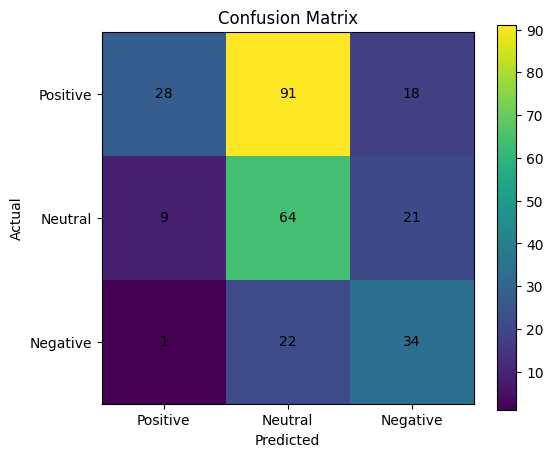

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.xticks(range(3), labels)
plt.yticks(range(3), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.show()